## CD Index — 5-Year Window (CD_5)

We compute CD over a **5-year citation window** following Park et al. (2023).
This means only citations received within 5 years of publication count toward ni and nj.

**Why 5 years?**
- Standard in bibliometrics literature (Park et al. 2023, Nature)
- Captures early citation momentum before papers saturate
- Consistent across all 890 papers regardless of age
- Avoids noise from very recent papers with few citations yet

In [17]:
import pandas as pd
import numpy as np
import requests
import time
from pathlib import Path

ROOT = Path("..")
MATCHED = ROOT / "data" / "matched"
FIGURES = ROOT / "data" / "figures"

In [18]:
API_KEY = "A08hCjeUoeVKA9toVsfCpF"  # paste from openalex.org/settings/api

def get_references(work_id):
    url = f"https://api.openalex.org/works/{work_id}"
    r = requests.get(url, params={"api_key": API_KEY})
    if r.status_code != 200:
        return []
    refs = r.json().get("referenced_works", [])
    return [ref.split("/")[-1] for ref in refs]

def get_citations(work_id, focal_year, window=5):
    url = "https://api.openalex.org/works"
    params = {
        "filter": f"cites:{work_id},publication_year:{focal_year}-{focal_year+window}",
        "per-page": 200,
        "api_key": API_KEY
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        return []
    return [w['id'].split("/")[-1] for w in r.json().get("results", [])]

def get_refs_of_citer(citer_id):
    url = f"https://api.openalex.org/works/{citer_id}"
    r = requests.get(url, params={"api_key": API_KEY})
    if r.status_code != 200:
        return set()
    refs = r.json().get("referenced_works", [])
    return set(ref.split("/")[-1] for ref in refs)

In [19]:
df = pd.read_csv(MATCHED / "huang_matched_openalex.csv")
print(df.shape)
print(df.columns.tolist())
df.head(3)

(912, 10)
['year', 'conference', 'paper_title', 'paper_url', 'authors', 'openalex_id', 'doi', 'match_route', 'oa_title', 'authorships']


,year,conference,paper_title,paper_url,authors,openalex_id,doi,match_route,oa_title,authorships
0,2018,AAAI,Memory-Augmented Monte Carlo Tree Search,https://www.semanticscholar.org/paper/2d7fb18f...,"Chenjun Xiao, University of Alberta ; et al. J...",https://openalex.org/W2788603415,10.1609/aaai.v32i1.11531,SS→DOI→OA,Memory-Augmented Monte Carlo Tree Search,"[{'author_position': 'first', 'author': {'id':..."
1,2018,ACL,Finding syntax in human encephalography with b...,https://www.semanticscholar.org/paper/8981a71b...,"John Hale, Cornell University ; et al. Chris D...",https://openalex.org/W2798397965,10.18653/v1/P18-1254,SS→DOI→OA,Finding syntax in human encephalography with b...,"[{'author_position': 'first', 'author': {'id':..."
2,2018,ACL,Learning to Ask Good Questions: Ranking Clarif...,https://scholar.google.com/scholar?as_q=&num=1...,"Sudha Rao & Hal Daumé III, University of Maryland",https://openalex.org/W2963033005,NaN,GS→title→OA,Learning to Ask Good Questions: Ranking Clarif...,"[{'author_position': 'first', 'author': {'id':..."


In [20]:
juniors = pd.read_csv(MATCHED / "junior_authors_all_conferences.csv")
print(f"Juniors: {juniors['author_id'].nunique()}")

# Check what columns link to award papers
print(juniors.columns.tolist())

Juniors: 603
['award_id', 'conference', 'award_year', 'work_id', 'award_title', 'author_id', 'author_name', 'author_position', 'career_age_at_award', 'total_pubs_at_award', 'institutions', 'is_corresponding', 'match_route', 'core_rank']


In [21]:
# Fix: column is openalex_id not work_id
print(df[['openalex_id', 'year']].dropna().shape)
print(df['year'].value_counts().sort_index())

(890, 2)
year
2000    14
2001    16
2002    13
2003    28
2004    29
2005    39
2006    28
2007    43
2008    46
2009    45
2010    50
2011    55
2012    52
2013    66
2014    70
2015    76
2016    79
2017    75
2018    88
Name: count, dtype: int64


In [22]:
# Strip full URL to bare ID
df['work_id'] = df['openalex_id'].str.extract(r'(W\d+)')
print(df['work_id'].isna().sum(), "missing IDs")
print(df[['work_id','year','conference']].head(3))

22 missing IDs
       work_id  year conference
0  W2788603415  2018       AAAI
1  W2798397965  2018        ACL
2  W2963033005  2018        ACL


In [23]:
def get_references(work_id):
    url = f"https://api.openalex.org/works/{work_id}"
    r = requests.get(url, params={"mailto": "your@email.com"})
    if r.status_code != 200:
        return []
    refs = r.json().get("referenced_works", [])
    return [ref.split("/")[-1] for ref in refs]  # strip to W-ID

pilot = df['work_id'].dropna().head(5).tolist()
for wid in pilot:
    refs = get_references(wid)
    print(f"{wid} → {len(refs)} refs")
    time.sleep(0.5)

W2788603415 → 35 refs
W2798397965 → 33 refs
W2963033005 → 33 refs
W2899300759 → 129 refs
W4255717503 → 27 refs


In [24]:
def get_citations(work_id, focal_year, window=5):
    url = "https://api.openalex.org/works"
    params = {
        "filter": f"cites:{work_id},publication_year:{focal_year}-{focal_year+window}",
        "per-page": 200,
        "mailto": "your@email.com"
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        return []
    return [w['id'].split("/")[-1] for w in r.json().get("results", [])]

# Test on first paper
wid = pilot[0]
year = df.loc[df['work_id']==wid, 'year'].values[0]
cites = get_citations(wid, year)
print(f"{wid} ({year}) → {len(cites)} citing papers in 5yr window")

W2788603415 (2018) → 18 citing papers in 5yr window


In [25]:
def get_refs_of_citer(citer_id):
    """Get what a citing paper itself cites"""
    url = f"https://api.openalex.org/works/{citer_id}"
    r = requests.get(url, params={"mailto": "your@email.com"})
    if r.status_code != 200:
        return set()
    refs = r.json().get("referenced_works", [])
    return set(ref.split("/")[-1] for ref in refs)

# Pilot: focal paper W2788603415
focal_id = "W2788603415"
focal_year = 2018
focal_refs = set(get_references(focal_id))
focal_cites = get_citations(focal_id, focal_year)

print(f"Refs: {len(focal_refs)}, Citers: {len(focal_cites)}")
time.sleep(0.3)

Refs: 35, Citers: 18


In [13]:
ni, nj = 0, 0

for citer in focal_cites:
    citer_refs = get_refs_of_citer(citer)
    overlap = citer_refs & focal_refs  # citer also cites focal's refs?
    if overlap:
        nj += 1  # cites focal AND its refs
    else:
        ni += 1  # cites focal only → disruptive signal
    time.sleep(0.15)

# nk = papers citing only refs (hard to get, often set to 0)
nk = 0

cd = (ni - nj) / (ni + nj + nk) if (ni + nj + nk) > 0 else np.nan
print(f"ni={ni}, nj={nj}, nk={nk}")
print(f"CD Index = {cd:.3f}")

ni=5, nj=13, nk=0
CD Index = -0.444


In [26]:
from concurrent.futures import ThreadPoolExecutor

# Resume from where we left off
done = set(pd.read_csv(MATCHED / "cd_results.csv")['work_id']) if (MATCHED / "cd_results.csv").exists() else set()
remaining = df[~df['work_id'].isin(done)].dropna(subset=['work_id'])
print(f"Already done: {len(done)} | Remaining: {len(remaining)}")

results = []

def process_citer(args):
    citer, refs = args
    citer_refs = get_refs_of_citer(citer)
    time.sleep(0.05)
    return bool(citer_refs & refs)

for i, row in remaining.iterrows():
    focal_id = row['work_id']
    focal_year = int(row['year'])
    
    try:
        refs = set(get_references(focal_id))
        cites = get_citations(focal_id, focal_year)
        
        with ThreadPoolExecutor(max_workers=5) as ex:
            overlaps = list(ex.map(process_citer, [(c, refs) for c in cites]))
        
        nj = sum(overlaps)
        ni = len(overlaps) - nj
        cd = (ni - nj) / (ni + nj) if (ni + nj) > 0 else np.nan
        
        results.append({'work_id': focal_id, 'year': focal_year,
                        'conference': row['conference'],
                        'ni': ni, 'nj': nj, 'cd_5': cd})
        print(f"[{i}] {focal_id} → CD={cd:.3f} (ni={ni}, nj={nj})")
    
    except Exception as e:
        print(f"[{i}] {focal_id} ERROR: {e}")
    
    time.sleep(0.1)

# Append to existing results
df_new = pd.DataFrame(results)
if (MATCHED / "cd_results.csv").exists():
    df_cd = pd.concat([pd.read_csv(MATCHED / "cd_results.csv"), df_new], ignore_index=True)
else:
    df_cd = df_new

df_cd.to_csv(MATCHED / "cd_results.csv", index=False)
print(f"\n✅ Done! {len(df_cd)} total papers. Median CD: {df_cd['cd_5'].median():.3f}")

Already done: 0 | Remaining: 890
[0] W2788603415 → CD=-0.444 (ni=5, nj=13)
[1] W2798397965 → CD=-0.889 (ni=1, nj=17)
[2] W2963033005 → CD=0.082 (ni=66, nj=56)
[3] W2899300759 → CD=-1.000 (ni=0, nj=8)
[4] W4255717503 → CD=-0.867 (ni=2, nj=28)
[5] W2796228338 → CD=-0.596 (ni=39, nj=154)
[6] W2795857247 → CD=-0.884 (ni=7, nj=114)
[7] W2889312863 → CD=1.000 (ni=3, nj=0)
[8] W2796063124 → CD=-0.162 (ni=31, nj=43)
[9] W2796122895 → CD=-0.172 (ni=12, nj=17)
[10] W2795975316 → CD=-0.305 (ni=33, nj=62)
[11] W2795736453 → CD=-0.381 (ni=13, nj=29)
[12] W2795908329 → CD=0.169 (ni=90, nj=64)
[13] W2795620203 → CD=1.000 (ni=7, nj=0)
[14] W2787712888 → CD=-0.280 (ni=72, nj=128)
[15] W2795582800 → CD=-0.421 (ni=11, nj=27)
[16] W2795389852 → CD=-0.200 (ni=40, nj=60)
[17] W2795783386 → CD=-0.188 (ni=13, nj=19)
[18] W2796076588 → CD=-0.500 (ni=20, nj=60)
[19] W2807472134 → CD=-1.000 (ni=0, nj=13)
[20] W2795429875 → CD=-0.821 (ni=6, nj=61)
[21] W2795442664 → CD=-0.244 (ni=17, nj=28)
[22] W2795619128 → CD=

In [27]:
df_cd = pd.read_csv(MATCHED / "cd_results.csv")

# Flag unreliable scores
df_cd['total_citers'] = df_cd['ni'] + df_cd['nj']
df_cd['cd_reliable'] = df_cd['cd_5'].where(df_cd['total_citers'] >= 10)

print(f"Total papers:     {len(df_cd)}")
print(f"Reliable (≥10):   {df_cd['cd_reliable'].notna().sum()}")
print(f"Unreliable (<10): {df_cd['cd_reliable'].isna().sum()}")
print(f"\nMedian CD (reliable only): {df_cd['cd_reliable'].median():.3f}")

df_cd.to_csv(MATCHED / "cd_results_filtered.csv", index=False)

Total papers:     890
Reliable (≥10):   811
Unreliable (<10): 79

Median CD (reliable only): -0.571


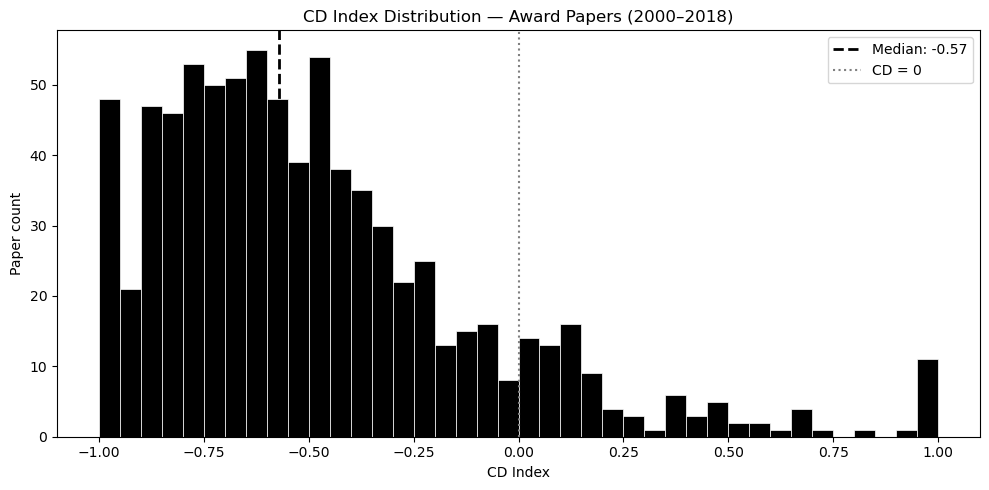

✅ Saved!


In [30]:
import matplotlib.pyplot as plt

reliable = df_cd['cd_reliable'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(reliable, bins=40, color='black', edgecolor='white', linewidth=0.5)
ax.axvline(reliable.median(), color='black', linestyle='--', linewidth=2,
           label=f'Median: {reliable.median():.2f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='CD = 0')
ax.set_xlabel('CD Index')
ax.set_ylabel('Paper count')
ax.set_title('CD Index Distribution — Award Papers (2000–2018)')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "20_cd_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [33]:
# Cell 13
core = pd.read_csv(MATCHED / "conference_core_ranks.csv")
df_cd = df_cd.merge(core, on='conference', how='left')
print(df_cd.groupby('core_rank')['cd_reliable'].median().sort_values(ascending=False))

core_rank
A*         -0.550000
Unranked   -0.626168
Name: cd_reliable, dtype: float64


In [35]:
# Add missing ranks
missing_ranks = {
    'FSE':     'A*',
    'UIST':    'A',
    'PLDI':    'A*',
    'ACL':     'A*',
    'KDD':     'A*',
    'PODS':    'A*',
    'WWW':     'A*',
    'CIKM':    'A',
    'NeurIPS': 'A*'
}

df_cd['core_rank'] = df_cd.apply(
    lambda r: missing_ranks.get(r['conference'], r['core_rank']), axis=1
)

print(df_cd['core_rank'].value_counts(dropna=False))
print("\nMedian CD by tier:")
print(df_cd.groupby('core_rank')['cd_reliable'].median().sort_values(ascending=False))

core_rank
A*          819
A            50
Unranked     21
Name: count, dtype: int64

Median CD by tier:
core_rank
A          -0.530000
A*         -0.571429
Unranked   -0.626168
Name: cd_reliable, dtype: float64


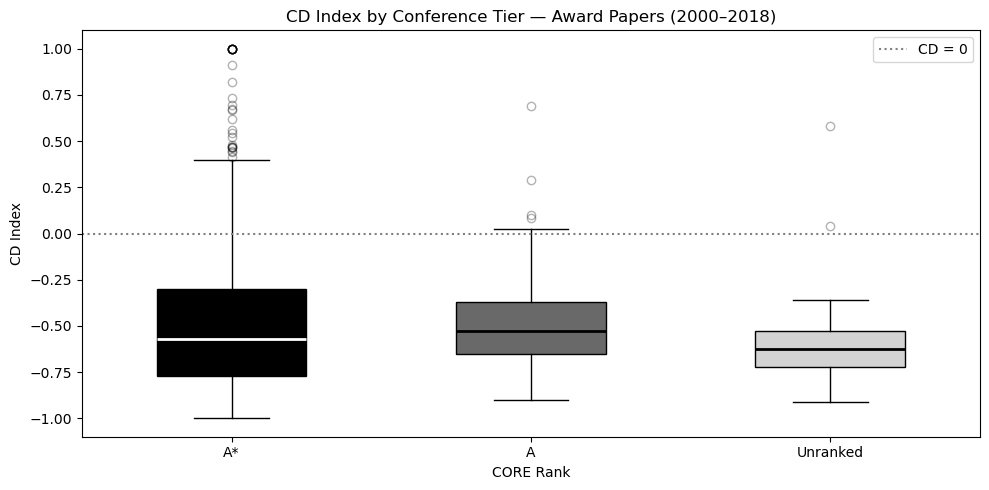

✅ Saved!


In [36]:
import matplotlib.pyplot as plt
import numpy as np

tiers = ['A*', 'A', 'Unranked']
colors = ['black', 'dimgray', 'lightgray']

fig, ax = plt.subplots(figsize=(10, 5))

for tier, color in zip(tiers, colors):
    data = df_cd[df_cd['core_rank'] == tier]['cd_reliable'].dropna()
    ax.boxplot(data, positions=[tiers.index(tier)],
               widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=color, color='black'),
               medianprops=dict(color='white' if color == 'black' else 'black', linewidth=2),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               flierprops=dict(marker='o', color='black', alpha=0.3))

ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='CD = 0')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(tiers)
ax.set_xlabel('CORE Rank')
ax.set_ylabel('CD Index')
ax.set_title('CD Index by Conference Tier — Award Papers (2000–2018)')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "20_cd_by_tier.png"), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

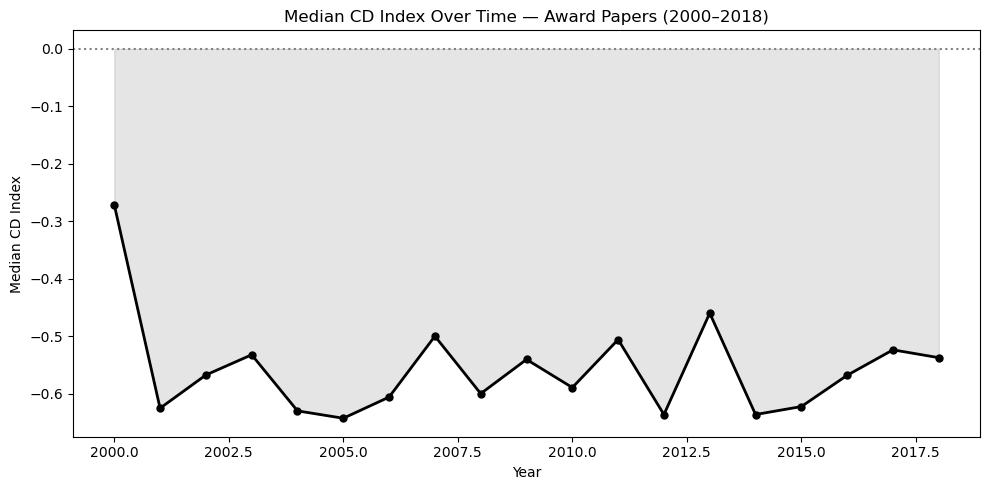

    year  cd_reliable
0   2000    -0.271233
1   2001    -0.625397
2   2002    -0.567592
3   2003    -0.532407
4   2004    -0.630000
5   2005    -0.642857
6   2006    -0.606006
7   2007    -0.500000
8   2008    -0.600000
9   2009    -0.540541
10  2010    -0.589433
11  2011    -0.505952
12  2012    -0.636364
13  2013    -0.459936
14  2014    -0.636364
15  2015    -0.622500
16  2016    -0.568098
17  2017    -0.523810
18  2018    -0.537446


In [37]:
import matplotlib.pyplot as plt

cd_time = df_cd.groupby('year')['cd_reliable'].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cd_time['year'], cd_time['cd_reliable'], color='black', linewidth=2, marker='o', markersize=5)
ax.fill_between(cd_time['year'], cd_time['cd_reliable'], alpha=0.1, color='black')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='CD = 0')
ax.set_xlabel('Year')
ax.set_ylabel('Median CD Index')
ax.set_title('Median CD Index Over Time — Award Papers (2000–2018)')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "20_cd_over_time.png"), dpi=150, bbox_inches='tight')
plt.show()
print(cd_time.to_string())

In [39]:
# Load citation lift
lifts = pd.read_csv(MATCHED / "author_lift.csv")
print(lifts.columns.tolist())  # check columns first

# Aggregate author lift to paper level (median lift per conference+year)
lift_agg = lifts[lifts['treatment'] == 1].groupby(['conference', 'award_year']).agg(
    lift_citations=('lift_citations', 'median'),
    lift_works=('lift_works', 'median')
).reset_index().rename(columns={'award_year': 'year'})

# Merge with CD
df_cd_lift = df_cd.merge(lift_agg, on=['conference', 'year'], how='inner')
print(f"Merged: {len(df_cd_lift)} papers")
print(df_cd_lift[['cd_reliable', 'lift_citations']].dropna().shape)

['author_id', 'author_name', 'treatment', 'conference', 'award_year', 'pre_avg_citations', 'post_avg_citations', 'pre_avg_works', 'post_avg_works', 'lift_citations', 'lift_works']
Merged: 650 papers
(591, 2)


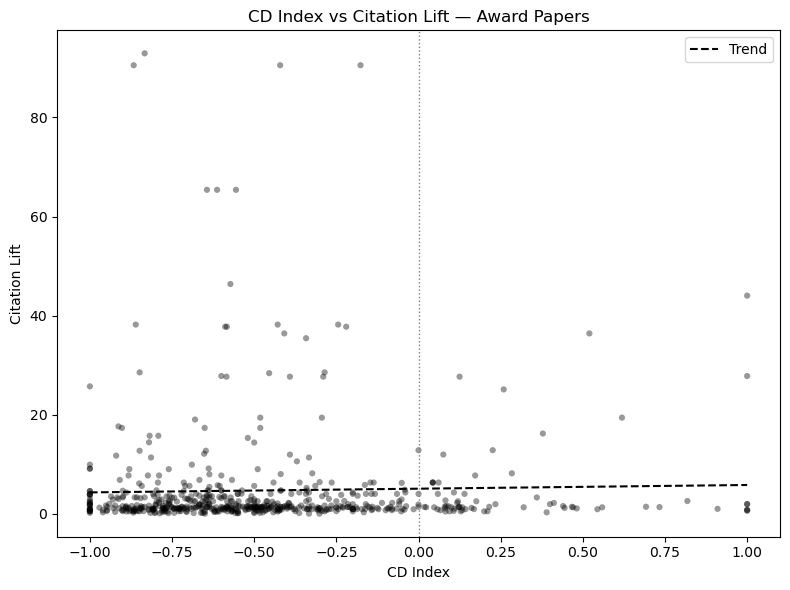

Pearson r = 0.027


In [40]:
plot_df = df_cd_lift[['cd_reliable', 'lift_citations']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df['cd_reliable'], plot_df['lift_citations'],
           color='black', alpha=0.4, s=20, edgecolors='none')

# Trend line
z = np.polyfit(plot_df['cd_reliable'], plot_df['lift_citations'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_df['cd_reliable'].min(), plot_df['cd_reliable'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, label='Trend')

ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('CD Index')
ax.set_ylabel('Citation Lift')
ax.set_title('CD Index vs Citation Lift — Award Papers')
ax.legend()
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(str(FIGURES / "20_cd_vs_citation_lift.png"), dpi=150, bbox_inches='tight')
plt.show()

corr = plot_df.corr().loc['cd_reliable', 'lift_citations']
print(f"Pearson r = {corr:.3f}")

#### CD Index Distribution
Most award papers cluster between -1.0 and 0, heavily left-skewed. Only ~15% score above CD=0, meaning very few award papers are genuinely disruptive — the field rewards consolidating work.

#### CD by Conference Tier
All tiers are consolidating, but A* has the widest spread — more outlier disruptive papers exist at top venues. Unranked conferences are the most consistently consolidating (tight box, low median).

#### CD Over Time
2000 was the most disruptive year (median ~-0.30), then a sharp drop to -0.63 by 2001 that never recovered. After 2001, CD stays flat around -0.55 with no clear trend — CS award papers have been consistently consolidating for 20 years.

#### CD vs Citation Lift
Weak positive trend — slightly more consolidating papers (-1.0 side) actually get high citation lifts too. No strong relationship, meaning disruption does not predict citation impact for award papers. The outliers (citation lift >40) appear across the full CD range.

- CS best paper awards go predominantly to consolidating work. Disruption is rare, stable over time, and does not predict citation impact — suggesting award committees reward incremental excellence over paradigm shifts.